In [1]:
import time
import matplotlib.pyplot as plt
import cantera as ct

In [2]:

gas = ct.Solution("n-hexane-NUIG-2015.yaml")

reactor_temperature = 925  # Kelvin
reactor_pressure = 1.046138 * ct.one_atm  # in atm. This equals 1.06 bars
inlet_concentrations = {"NC7H16": 0.005, "O2": 0.0275, "HE": 0.9675}
gas.TPX = reactor_temperature, reactor_pressure, inlet_concentrations

residence_time = 2  # s
reactor_volume = 30.5 * (1e-2) ** 3  # m3

# Simulation termination criterion
max_simulation_time = 50  # seconds

# Create reservoirs for the inlet and exhaust
fuel_air_mixture_tank = ct.Reservoir(gas)
exhaust = ct.Reservoir(gas)

# Create the stirred reactor
# energy="off" means the reactor is isothermal (temperature is fixed)
stirred_reactor = ct.IdealGasMoleReactor(gas, energy="off", volume=reactor_volume)

# Create a mass flow controller to control the inlet flow rate
mass_flow_controller = ct.MassFlowController(
    upstream=fuel_air_mixture_tank,
    downstream=stirred_reactor,
    mdot=stirred_reactor.mass / residence_time,
)

# Create a pressure regulator to maintain constant pressure in the reactor
pressure_regulator = ct.PressureController(
    upstream=stirred_reactor,
    downstream=exhaust,
    primary=mass_flow_controller,
    K=1e-3, # Proportional gain 
)


C:\Users\9pabl\AppData\Local\Temp\ipykernel_51908\3975839797.py:1: UserWarning: NasaPoly2::validate: 
For species OHV, discontinuity in h/RT detected at Tmid = 1000
	Value computed using low-temperature polynomial:  53.62056162666667
	Value computed using high-temperature polynomial: 53.5841554314

  gas = ct.Solution("n-hexane-NUIG-2015.yaml")
C:\Users\9pabl\AppData\Local\Temp\ipykernel_51908\3975839797.py:1: UserWarning: NasaPoly2::validate: 
For species CHV, discontinuity in h/RT detected at Tmid = 1000
	Value computed using low-temperature polynomial:  107.5046684
	Value computed using high-temperature polynomial: 107.34847808033332

  gas = ct.Solution("n-hexane-NUIG-2015.yaml")


In [3]:

# Create a reactor network
reactor_network = ct.ReactorNet([stirred_reactor])

# Create a SolutionArray to store the data
time_history = ct.SolutionArray(gas, extra=["t"])

# Set the maximum simulation time
max_simulation_time = 50  # seconds

# Start the stopwatch
tic = time.time()

# Set simulation start time to zero
t = 0
counter = 1
while t < max_simulation_time:
    t = reactor_network.step()

    # Store data periodically (e.g., every 10 steps) to reduce memory usage
    if counter % 10 == 0:
        # Extract the state of the reactor
        time_history.append(stirred_reactor.thermo.state, t=t)

    counter += 1

# Stop the stopwatch
toc = time.time()

print(f"Simulation Took {toc-tic:3.2f}s to compute, with {counter} steps")

Simulation Took 43.62s to compute, with 457 steps


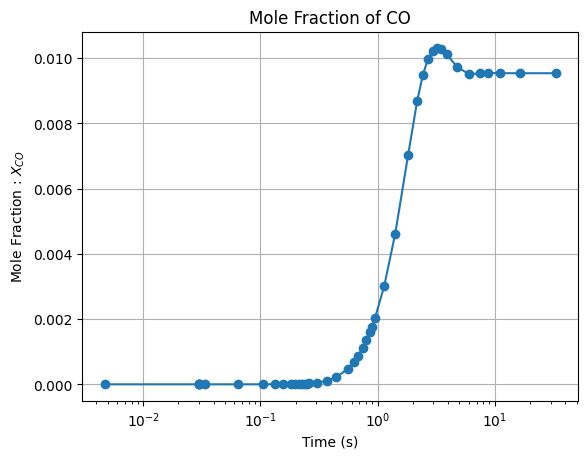

In [4]:
plt.figure()
plt.semilogx(time_history.t, time_history("CO").X, "-o")
plt.xlabel("Time (s)")
plt.ylabel("Mole Fraction : $X_{CO}$")
plt.title("Mole Fraction of CO")
plt.grid()
plt.show()